Analisi delle violazioni SLA sul dataset worst-case dei datapacket.

Ogni osservazione rappresenta il datapacket con Total Delay massimo all’interno di una specifica combinazione Distribution-Scenario-App_ms-Run.

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_pickle("processed_data/dataset_worst_case_datapacket_user.pkl")
df.head(1)

,Distribution,Scenario,App_ms,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Violation_Percentage,Processing Delay,Propagation Delay,Hops
0,exponential,1_26_solution_v0,1SMM,run_0,1,1,72,63.486,True,13.41,45,27,"[{'hop_index': 0, 'link_index': 0, 'source': 1..."


In [101]:
df['SLA_Margin'] = df['Total Delay'] - df['Delay SLAs']
df['Violation_Amount'] = df['SLA_Margin'].clip(lower=0)
df['SLA_Violation_Int'] = df['SLA_Violation'].astype(int)
df.head()

,Distribution,Scenario,App_ms,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Violation_Percentage,Processing Delay,Propagation Delay,Hops,SLA_Margin,Violation_Amount,SLA_Violation_Int
0,exponential,1_26_solution_v0,1SMM,run_0,1,1,72,63.486,True,13.41,45,27,"[{'hop_index': 0, 'link_index': 0, 'source': 1...",8.514,8.514,1
1,exponential,1_26_solution_v0,1SMM,run_1,1,1,37,63.486,False,-41.72,10,27,"[{'hop_index': 0, 'link_index': 0, 'source': 1...",-26.486,0.000,0
2,exponential,1_26_solution_v0,1SMM,run_2,1,1,49,63.486,False,-22.82,22,27,"[{'hop_index': 0, 'link_index': 0, 'source': 1...",-14.486,0.000,0
3,exponential,1_26_solution_v0,1SMM,run_3,1,1,52,63.486,False,-18.09,25,27,"[{'hop_index': 0, 'link_index': 0, 'source': 1...",-11.486,0.000,0
4,exponential,1_26_solution_v0,1SMM,run_4,1,1,48,63.486,False,-24.39,21,27,"[{'hop_index': 0, 'link_index': 0, 'source': 1...",-15.486,0.000,0


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Distribution              1440 non-null   str    
 1   Scenario                  1440 non-null   str    
 2   App_ms                    1440 non-null   str    
 3   Run                       1440 non-null   str    
 4   User                      1440 non-null   int64  
 5   Application               1440 non-null   int64  
 6   Total Delay               1440 non-null   int64  
 7   Delay SLAs                1440 non-null   float64
 8   SLA_Violation             1440 non-null   bool   
 9   SLA_Violation_Percentage  1440 non-null   float64
 10  Processing Delay          1440 non-null   int64  
 11  Propagation Delay         1440 non-null   int64  
 12  Hops                      1440 non-null   object 
 13  SLA_Margin                1440 non-null   float64
 14  Violation_Amount   

In [77]:
print("SLA violation", df['SLA_Violation'].sum(), "out of", len(df))
print(f"SLA violation rate: {df['SLA_Violation'].mean() * 100:.2f}%")


SLA violation 58 out of 1440
SLA violation rate: 4.03%


In [95]:
dist_summary = df.groupby('Distribution').agg(
        Runs=('Run', 'count'),
        Violations=('SLA_Violation', 'sum'),
        Violation_Rate=('SLA_Violation_Int', 'mean'),
        Mean_Total_Delay=('Total Delay', 'mean'),
        Median_Total_Delay=('Total Delay', 'median'),
        Max_Total_Delay=('Total Delay', 'max'),
        Mean_Violation_Amount=('Violation_Amount', 'mean'),
        Max_Violation_Amount=('Violation_Amount', 'max')
    ).reset_index()

dist_summary['Violation_Rate'] = (dist_summary['Violation_Rate'] * 100).round(2)
dist_summary

,Distribution,Runs,Violations,Violation_Rate,Mean_Total_Delay,Median_Total_Delay,Max_Total_Delay,Mean_Violation_Amount,Max_Violation_Amount
0,exponential,480,49,10.21,57.852083,56.0,105,0.731079,18.448
1,gaussian,480,0,0.00,60.437500,58.5,81,0.000000,0.000
2,uniform,480,9,1.88,59.222917,58.0,87,0.031844,4.766


La distribuzione esponenziale risulta la più critica rispetto al rispetto della SLA. Pur mostrando valori medi e mediani del worst-case delay comparabili con quelli delle altre distribuzioni, presenta una percentuale di violazione nettamente superiore (10.21%) e il massimo ritardo osservato più elevato (105). Questo suggerisce che la differenza principale non risiede nel comportamento medio, ma nella maggiore presenza di casi estremi.
La distribuzione gaussiana risulta invece la più robusta, non mostrando alcuna violazione SLA nelle 480 run analizzate. La distribuzione uniforme assume un comportamento intermedio, con un numero limitato di violazioni e una severità contenuta.

In [100]:
app_summary = df.groupby('App_ms').agg(
        Runs=('Run', 'count'),
        Violations=('SLA_Violation', 'sum'),
        Violation_Rate=('SLA_Violation', 'mean'),
        Mean_Total_Delay=('Total Delay', 'mean'),
        Median_Total_Delay=('Total Delay', 'median'),
        Max_Total_Delay=('Total Delay', 'max'),
        Mean_Violation_Amount=('Violation_Amount', 'mean'),
        Max_Violation_Amount=('Violation_Amount', 'max')
    ).reset_index()

app_summary['Violation_Rate'] = (app_summary['Violation_Rate'] * 100).round(2)
app_summary

,App_ms,Runs,Violations,Violation_Rate,Mean_Total_Delay,Median_Total_Delay,Max_Total_Delay,Mean_Violation_Amount,Max_Violation_Amount
0,1MMM,90,5,5.56,49.933333,51.5,75,0.397244,13.766
1,1MMS,90,0,0.00,56.866667,57.0,68,0.000000,0.000
2,1MSM,30,0,0.00,49.166667,51.0,56,0.000000,0.000
3,1MSS,30,0,0.00,52.833333,55.0,66,0.000000,0.000
4,1SMM,180,8,4.44,56.133333,55.0,81,0.362639,16.766
5,1SMS,180,6,3.33,55.600000,56.0,66,0.073917,4.766
6,1SSM,180,6,3.33,57.927778,58.0,90,0.345072,13.766
7,1SSS,180,11,6.11,59.005556,58.0,84,0.229656,6.766
8,2MMM,30,0,0.00,67.266667,67.0,86,0.000000,0.000
9,2MMS,30,0,0.00,67.866667,68.0,76,0.000000,0.000


Le applicazioni della famiglia 2 tendono ad avere, in media, Total Delay più alto rispetto a molte della famiglia 1.

Ci sono profili con delay medio alto ma senza violazioni, e profili con delay medio non necessariamente massimo ma con più violazioni. Per esempio:

- 2MMS ha delay medio molto alto, ma Violation_Rate = 0
- 2SMS ha delay medio simile, ma Violation_Rate = 10%

Il rispetto della SLA dipende non solo dal livello medio del worst-case delay, ma anche dalla variabilità e dalla vicinanza del ritardo osservato alla soglia prevista per quello specifico profilo applicativo.

Quindi, anche se 2SMS è il peggiore per frequenza di violazione, 2SSM è il più severo in termini di singola violazione massima.

Famiglia 1*

I profili 1* mostrano comportamento abbastanza eterogeneo:

alcuni non violano mai
altri, come 1SSS, 1SMM e 1MMM, mostrano violazioni non trascurabili
Famiglia 2*

I profili 2* tendono ad avere delay medi più alti, ma non tutti risultano critici per SLA:

2SMS è chiaramente il più problematico
2SMM e 2SSM mostrano anch’essi criticità
2MMM, 2MMS, 2MSM restano invece sempre entro soglia

Quindi all’interno della famiglia 2* non c’è un comportamento uniforme: alcuni profili sono robusti, altri molto più sensibili.

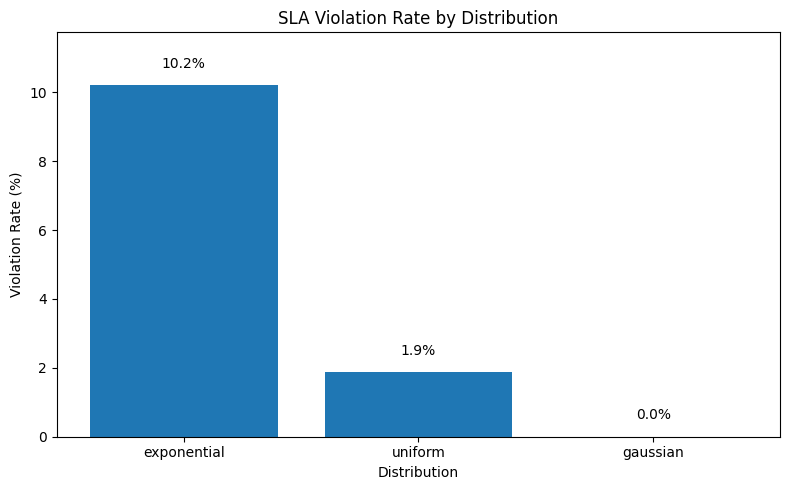

In [79]:
plot_df = dist_summary.sort_values('Violation_Rate', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df['Distribution'], plot_df['Violation_Rate'])
plt.title('SLA Violation Rate by Distribution')
plt.xlabel('Distribution')
plt.ylabel('Violation Rate (%)')
plt.ylim(0, max(plot_df['Violation_Rate'].max() * 1.15, 5))

for i, v in enumerate(plot_df['Violation_Rate']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

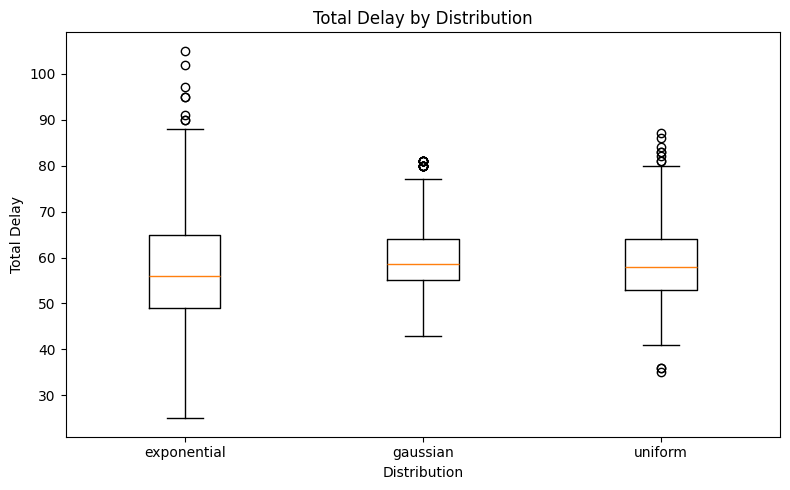

In [80]:
categories = sorted(df['Distribution'].dropna().unique())
data = [df.loc[df['Distribution'] == c, 'Total Delay'].dropna() for c in categories]

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('Total Delay by Distribution')
plt.xlabel('Distribution')
plt.ylabel('Total Delay')
plt.tight_layout()
plt.show()

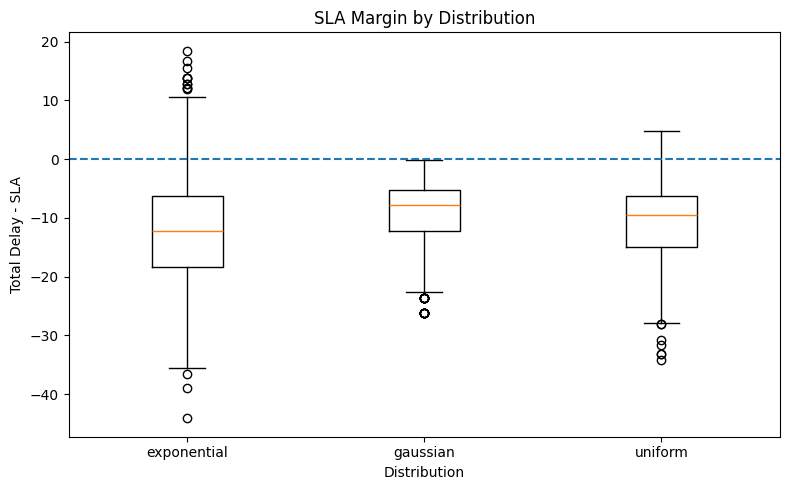

In [81]:
categories = sorted(df['Distribution'].dropna().unique())
data = [df.loc[df['Distribution'] == c, 'SLA_Margin'].dropna() for c in categories]

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=categories)
plt.axhline(0, linestyle='--')
plt.title('SLA Margin by Distribution')
plt.xlabel('Distribution')
plt.ylabel('Total Delay - SLA')
plt.tight_layout()
plt.show()

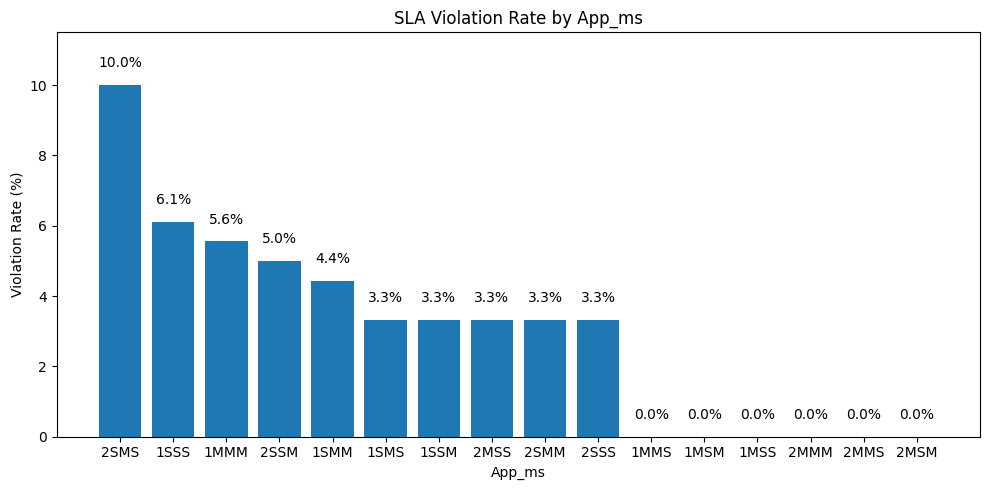

In [86]:
plot_df = app_summary.sort_values('Violation_Rate', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df['App_ms'], plot_df['Violation_Rate'])
plt.title('SLA Violation Rate by App_ms')
plt.xlabel('App_ms')
plt.ylabel('Violation Rate (%)')
plt.ylim(0, max(plot_df['Violation_Rate'].max() * 1.15, 5))

for i, v in enumerate(plot_df['Violation_Rate']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

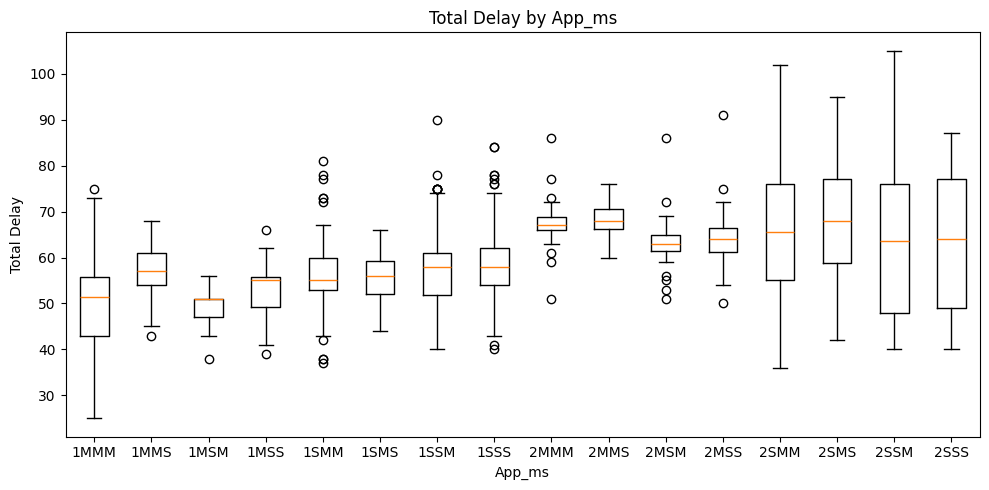

In [87]:
categories = sorted(df['App_ms'].dropna().unique())
data = [df.loc[df['App_ms'] == c, 'Total Delay'].dropna() for c in categories]

plt.figure(figsize=(10, 5))
plt.boxplot(data, tick_labels=categories)
plt.title('Total Delay by App_ms')
plt.xlabel('App_ms')
plt.ylabel('Total Delay')
plt.tight_layout()
plt.show()

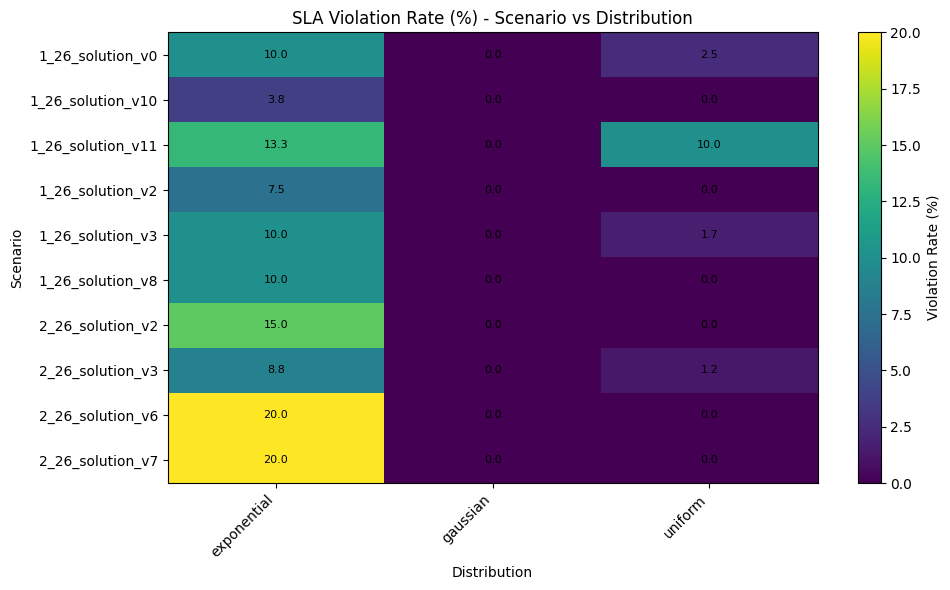

In [90]:
heatmap_data = (
    df.groupby(['Scenario', 'Distribution'])['SLA_Violation']
      .mean()
      .unstack() * 100
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_data.values, aspect='auto')

ax.set_title('SLA Violation Rate (%) - Scenario vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('Scenario')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Violation Rate (%)')

plt.tight_layout()
plt.show()

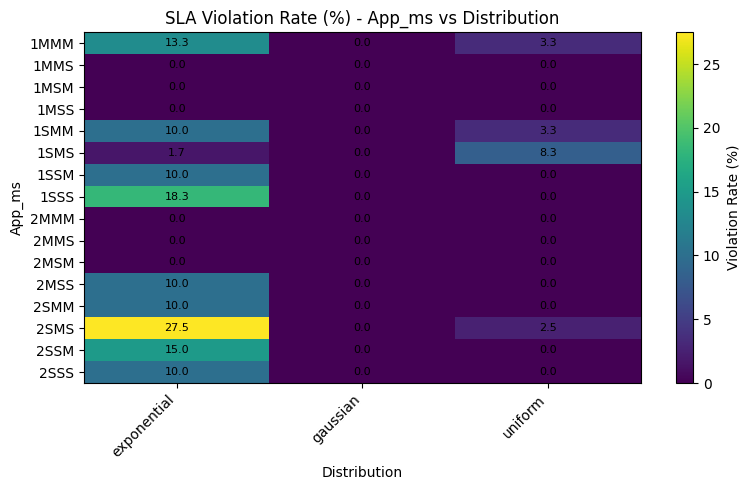

In [91]:
heatmap_data = (
    df.groupby(['App_ms', 'Distribution'])['SLA_Violation']
      .mean()
      .unstack() * 100
)

heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, aspect='auto')

ax.set_title('SLA Violation Rate (%) - App_ms vs Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('App_ms')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Violation Rate (%)')

plt.tight_layout()
plt.show()

In [92]:
combo_summary = (
    df.groupby(['Distribution', 'Scenario', 'App_ms'])
      .agg(
          Runs=('Run', 'count'),
          Violations=('SLA_Violation', 'sum'),
          Violation_Rate=('SLA_Violation', 'mean'),
          Mean_Total_Delay=('Total Delay', 'mean'),
          Max_Total_Delay=('Total Delay', 'max'),
          Mean_SLA_Margin=('SLA_Margin', 'mean'),
          Mean_Violation_Amount=('Violation_Amount', 'mean'),
          Max_Violation_Amount=('Violation_Amount', 'max')
      )
      .reset_index()
)

combo_summary['Violation_Rate'] = (combo_summary['Violation_Rate'] * 100).round(2)

combo_summary.head()

,Distribution,Scenario,App_ms,Runs,Violations,Violation_Rate,Mean_Total_Delay,Max_Total_Delay,Mean_SLA_Margin,Mean_Violation_Amount,Max_Violation_Amount
0,exponential,1_26_solution_v0,1SMM,10,1,10.0,51.7,72,-11.786,0.8514,8.514
1,exponential,1_26_solution_v0,1SMS,10,0,0.0,52.8,61,-10.686,0.0000,0.000
2,exponential,1_26_solution_v0,1SSM,10,1,10.0,54.5,74,-8.986,1.0514,10.514
3,exponential,1_26_solution_v0,1SSS,10,2,20.0,56.5,69,-6.986,1.1028,5.514
4,exponential,1_26_solution_v10,1MMM,10,0,0.0,41.1,62,-28.012,0.0000,0.000
